## Goal
#### Obtain the Absorption Spectra of Methane implementing turbo davidson
To run this tutorial we need to import QEpy and some of its modules

In [1]:
import qepy
from qepy.driver import Driver
from qepy.io import QEInput

In [ ]:
additional_files = {
    'H.pz-vbc.UPF' : 'https://pseudopotentials.quantum-espresso.org/upf_files/H.pz-vbc.UPF',
    'C.pz-vbc.UPF' : 'https://pseudopotentials.quantum-espresso.org/upf_files/C.pz-vbc.UPF',
}
from dftpy.formats import download_files
download_files(additional_files)

## Generate the QE options to run a scf calculation

In [2]:
scf_options = {
    '&control': {'calculation': "'scf'",
                 'prefix': "'CH4'",
                 'restart_mode': "'from_scratch'",
                 'outdir': "'tmp'",
                 'pseudo_dir' : "'./'",
                },
    '&system': {'celldm(1)': 20,
                'ecutwfc': 25,
                'ibrav': 1,
                'nat': 5,
                'nbnd': 20,
                'ntyp': 2},
    '&electrons': {'conv_thr': 1.0E-10},
    'atomic_positions {angstrom}': ['C   0.000000000   0.000000000   0.000000000',
                                    'H   0.642814093   0.642814093   0.642814093',
                                    'H  -0.642814093  -0.642814093   0.642814093',
                                    'H   0.642814093  -0.642814093  -0.642814093',
                                    'H  -0.642814093   0.642814093  -0.642814093'],
    'atomic_species': ['H  1.008  H.pz-vbc.UPF', 'C 12.011  C.pz-vbc.UPF'],
    'k_points {gamma}': [],
}

## Generate the QE options for the TDDFPT calculation

In [3]:
tddfpt_options = {
    '&lr_input': {'outdir': "'tmp'",
                  'prefix': "'CH4'",
                  'restart': False,
                 },
    '&lr_dav': {'num_basis_max': 80,
                'num_eign': 10,
                'num_init': 20,
                'p_nbnd_occ': 4,
                'p_nbnd_virt': 15,
                'reference': 0.5,
                'residue_conv_thr': 1.0E-4,
                'start': 0.0,
                'finish': 1.5,
                'broadening': 0.005,
                'step': 2.0E-4 ,
               },
}

 Write the options to input files for comparison with traditional command way

In [4]:
scf_in = 'CH4.scf.in'
tddfpt_in= 'CH4.tddfpt.in'
QEInput().write_qe_input(scf_in, qe_options=scf_options, prog='pw')
QEInput().write_qe_input(tddfpt_in, qe_options=tddfpt_options, prog='davidson')

In [5]:
!cat CH4.scf.in

&CONTROL
   calculation = 'scf'
   prefix = 'CH4'
   restart_mode = 'from_scratch'
   outdir = 'tmp'
   pseudo_dir = './'
/

&SYSTEM
   celldm(1) = 20
   ecutwfc = 25
   ibrav = 1
   nat = 5
   nbnd = 20
   ntyp = 2
/

&ELECTRONS
   conv_thr = 1e-10
/

&IONS
/

&CELL
/

&FCP
/

&RISM
/

ATOMIC_SPECIES
H  1.008  H.pz-vbc.UPF
C 12.011  C.pz-vbc.UPF

ATOMIC_POSITIONS {angstrom}
C   0.000000000   0.000000000   0.000000000
H   0.642814093   0.642814093   0.642814093
H  -0.642814093  -0.642814093   0.642814093
H   0.642814093  -0.642814093  -0.642814093
H  -0.642814093   0.642814093  -0.642814093

K_POINTS {gamma}



Download the PP with DFTpy

In [6]:
additional_files = {
    'H.pz-vbc.UPF' : 'https://pseudopotentials.quantum-espresso.org/upf_files/H.pz-vbc.UPF',
    'C.pz-vbc.UPF' : 'https://pseudopotentials.quantum-espresso.org/upf_files/C.pz-vbc.UPF',
}
from dftpy.formats import download_files
download_files(additional_files)

Initialize the Driver class with the scf QE options

In [7]:
driver = Driver(scf_in, task='scf', logfile='tmp.scf.out')

Run a scf calculation

In [8]:
driver.scf()

-15.777607360721099

We need to save the wave function for the TDDFT calculation

In [9]:
driver.save()

Initialize the Driver class with the tddfpt QE options to calculate the absorption spectra with truboDavidson

In [10]:
driver = Driver(tddfpt_in, task='tddfpt_davidson', logfile='tmp.tddfpt.out')

In [11]:
driver.scf()

0.0

In [12]:
driver.stop()

# Now we can plot the absorption spectra 

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
data = np.loadtxt('CH4.plot.dat')

Text(0, 0.5, 'Intensity (arb. units)')

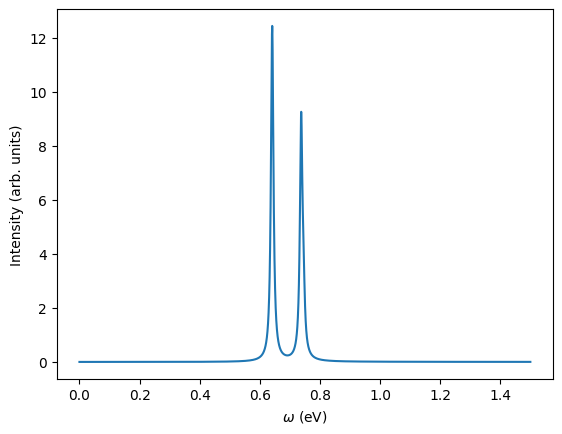

In [15]:
plt.plot(data[:,0], data[:,1])
plt.xlabel(r'$\omega$ (eV)')
plt.ylabel(r'Intensity (arb. units)')

# Challenge

<b>Compute the Absorption spectra of Mg8 cluster</b>

Important aspects:

Create another folder

Hint use the vasp file from the DFTpy tutorial and UPF file for the pseudopotential